## _Neural Data Science Project SoSe2026_ — Parameter inference with Jaxley

**Lecturer**: Prof. Dr. Philipp Berens, Dr. Jan Lause  
**Tutors**: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler  
**Student names**: Lucía Grande González, Andre Potthoff, Niclas Collmer  
**LLM Disclaimer**: Claude (Anthropic) was used to assist with code structure, debug JAX/Jaxley API usage, and refine summary statistics. All modelling decisions and scientific interpretation are our own.

## Context

The pyloric network of the stomatogastric ganglion (STG) is a well-studied component of the crustacean nervous system. It produces a rhythmic tri-phasic motor pattern (AB/PD → LP → PY) driven by a combination of intrinsic membrane currents and mutual inhibitory synapses.

We work with a **simplified 3-neuron model** (AB/PD merged, single LP, single PY) implemented in [Jaxley](https://jaxley.readthedocs.io/). The model has 7 synaptic connections:

| Edge | Pre | Post | Type |
|------|-----|------|------|
| 0 | AB/PD | LP | Glutamatergic |
| 1 | AB/PD | LP | Cholinergic |
| 2 | AB/PD | PY | Glutamatergic |
| 3 | AB/PD | PY | Cholinergic |
| 4 | LP | AB/PD | Glutamatergic |
| 5 | LP | PY | Glutamatergic |
| 6 | PY | LP | Glutamatergic |


papers with more context:
[Similar network activity from disparate circuit parameters](https://www.nature.com/articles/nn1352); [Alternative to hand-tuning conductance-based models](https://journals.physiology.org/doi/full/10.1152/jn.00641.2003); [Training deep neural density estimators to identify mechanistic models of neural dynamics](https://elifesciences.org/articles/56261)

#### The Model
<img src="network.png" alt="image-2.png" width="800"/>

### Research question
> **What synaptic conductances gave rise to the recorded trace, and is there more than one viable parameter set?**

## 1  Setup

In [1]:
from jax import config

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".8"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

import jaxley as jx
import jax
import jax.numpy as jnp
from jaxley_models import PyloricNetwork

from scipy.optimize import differential_evolution

from utils import *

matplotlib.rcParams["figure.dpi"] = 100
print("JAX version:", jax.__version__)
print("Jaxley version:", jx.__version__)


JAX version: 0.10.2
Jaxley version: 0.13.0


## 2  Data loading & exploratory analysis

In [2]:
t_obs, *v_obs_list = np.loadtxt("../data/pyloric_observation.csv", unpack=True)
v_obs = np.array(v_obs_list)  # shape (3, T)
dt_obs = float(t_obs[1] - t_obs[0])
T_obs = float(t_obs[-1])

print(f"Observation: {v_obs.shape[1]} timesteps, dt={dt_obs:.3f} ms, T={T_obs:.0f} ms")
print(f"V range:     [{v_obs.min():.1f}, {v_obs.max():.1f}] mV")

Observation: 16000 timesteps, dt=0.250 ms, T=4000 ms
V range:     [-96.5, 63.2] mV


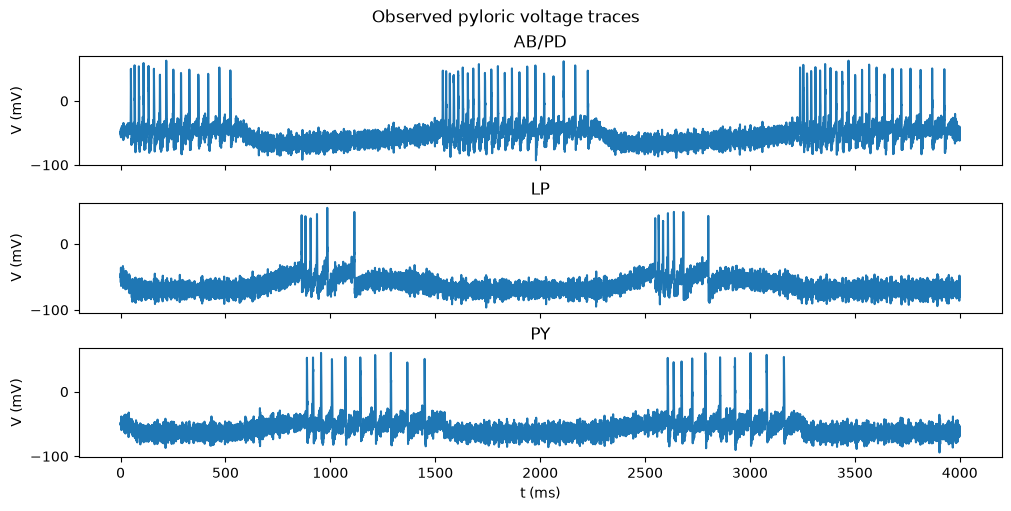

In [3]:
fig, axs = plot_pyloric(t_obs, v_obs)
fig.suptitle("Observed pyloric voltage traces", fontsize=12)
plt.show()

**Observations from the raw data:**
- Three neurons show rhythmic bursting with a period of roughly 1 – 2 s.
- AB/PD bursts first, followed ~half-period later by LP and PY (anti-phasic).
- Voltage swings between ≈ –96 mV (deep hyperpolarisation) and ≈ +63 mV (spikes), consistent with a GCaMP-free, direct patch-clamp style voltage recording.

In [4]:
# Summary statistics of the observation
stats_obs = summary_statistics(v_obs, dt=dt_obs, burn_in_ms=500.0)
print("Observation summary statistics:")
print_stats(stats_obs, label="obs")
print()
print("These are the targets we need to reproduce.")

Observation summary statistics:
  [obs] period (ms): 1666.583
  [obs] AB/PD duty cycle: 0.387
  [obs] LP duty cycle: 0.150
  [obs] PY duty cycle: 0.324
  [obs] LP phase: 0.573
  [obs] PY phase: 0.599
  [obs] AB/PD spikes/burst: 22.000
  [obs] LP spikes/burst: 6.500
  [obs] PY spikes/burst: 10.000

These are the targets we need to reproduce.


## 3  Model familiarisation

We first inspect the PyloricNetwork structure and confirm a single forward simulation works, then measure the compute cost of the full 4 s run.

In [5]:
net_demo = PyloricNetwork()
print("Nodes (neurons):")
node_cols = ["global_cell_index", "ab_pd", "lp", "py", "v", "Na_gNa", "capacitance"]
print(
    net_demo.nodes[
        [c for c in node_cols if c in net_demo.nodes.columns]
    ].drop_duplicates()
)
print()
print("Edges (synapses):")
edge_cols = [
    "global_edge_index",
    "pre_index",
    "post_index",
    "type",
    "GlutamatergicSynapse_gS",
    "CholinergicSynapse_gS",
]
print(net_demo.edges[[c for c in edge_cols if c in net_demo.edges.columns]])

Nodes (neurons):
   global_cell_index  ab_pd     lp     py     v  Na_gNa  capacitance
0                  0   True  False  False -50.0     0.3     0.999523
1                  1  False   True  False -50.0     0.1     0.999523
2                  2  False  False   True -50.0     0.5     0.999523

Edges (synapses):
   global_edge_index  pre_index  post_index                  type  \
0                  0          0           1  GlutamatergicSynapse   
1                  1          0           1    CholinergicSynapse   
2                  2          0           2  GlutamatergicSynapse   
3                  3          0           2    CholinergicSynapse   
4                  4          1           0  GlutamatergicSynapse   
5                  5          1           2  GlutamatergicSynapse   
6                  6          2           1  GlutamatergicSynapse   

   GlutamatergicSynapse_gS  CholinergicSynapse_gS  
0                   0.0001                    NaN  
1                      NaN     

### 3.1. Visualization of the Pyloric network

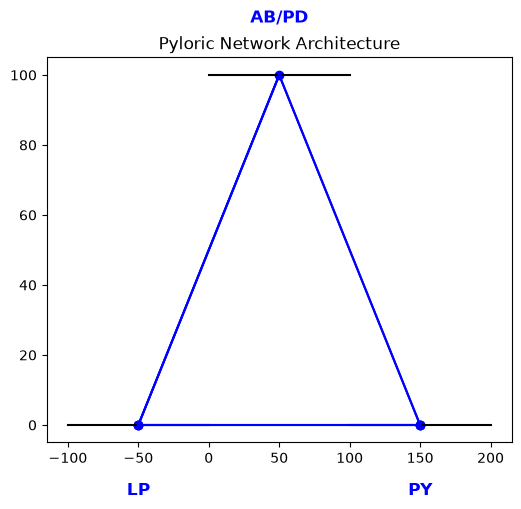

In [6]:
# 1. Initialize the internal 3D coordinates
net_demo.compute_xyz()

# 2. Move cells manually to an exact triangle shape using the integer indices from the table above
net_demo.cell(0).move_to(x=0, y=100, z=0)  # 0 = AB/PD
net_demo.cell(1).move_to(x=-100, y=0, z=0)  # 1 = LP
net_demo.cell(2).move_to(x=100, y=0, z=0)  # 2 = PY

# 3. Visualize the network
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
_ = net_demo.vis(ax=ax, detail="full", color="k")

# 4. Add the text labels near those coordinates
# 'ha' centers the text horizontally. We offset the 'y' coordinate slightly
# so the text floats just above or below the neuron.
ax.text(50, 115, "AB/PD", fontsize=12, fontweight="bold", ha="center", color="blue")
ax.text(-50, -20, "LP", fontsize=12, fontweight="bold", ha="center", color="blue")
ax.text(150, -20, "PY", fontsize=12, fontweight="bold", ha="center", color="blue")

# 5. Clean up the plot and show
plt.title("Pyloric Network Architecture")
plt.show()

### 3.3. Forward simulation

Next, we run the simulator once end-to-end and reproduce a plot comparable to the observation from default parameters given by Prinz et al., (2003)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3


Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


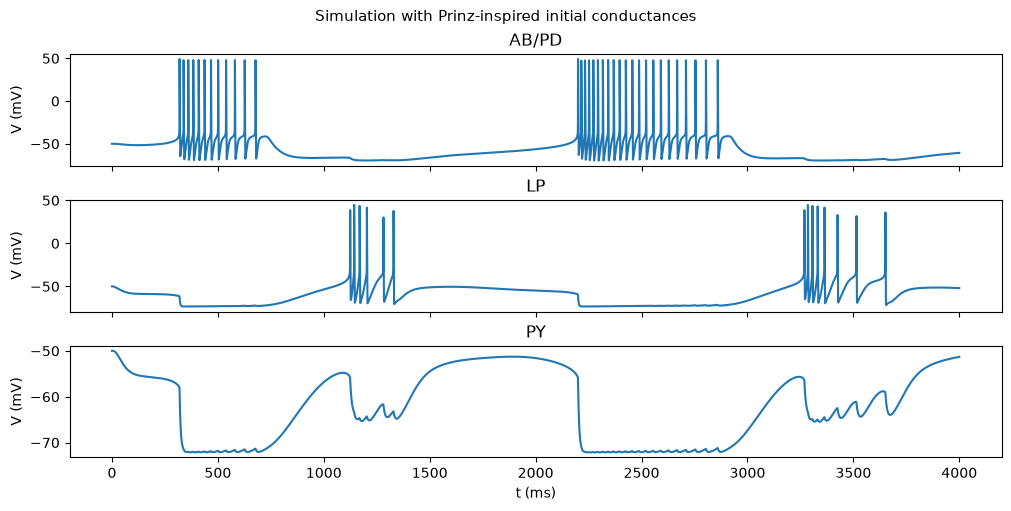

AB/PD: period=1881 ms, duty=0.27, n_bursts=2
LP: period=2144 ms, duty=0.14, n_bursts=2
PY: period=nan ms, duty=nan, n_bursts=0


In [7]:
# Default model trace (very weak synapses → near-intrinsic dynamics)

_, v_default = simulate(PRINZ_G_INIT_US, t_max=4000.0)


t_plot = np.arange(v_default.shape[1]) * 0.025
fig, axs = plot_pyloric(t_plot, v_default)
fig.suptitle("Simulation with Prinz-inspired initial conductances", fontsize=11)
plt.show()

for i, name in enumerate(["AB/PD", "LP", "PY"]):
    s = burst_stats_single(v_default[i], dt=0.025)
    print(
        f'{name}: period={s["period_ms"]:.0f} ms, duty={s["duty_cycle"]:.2f}, n_bursts={s["n_bursts"]}'
    )

## 4  Preprocessing & summary statistics

We compress the 4 s voltage trace into 9 scalar features:

| # | Statistic | Why it matters |
|---|-----------|----------------|
| 0 | Burst period (ms) | Network rhythm / primary pacemaker frequency |
| 1 | AB/PD duty cycle | Pacemaker active burst proportion |
| 2 | LP duty cycle | Second-phase active burst proportion |
| 3 | PY duty cycle | Third-phase active burst proportion |
| 4 | LP phase offset (relative to AB/PD) | Triphasic coordination / firing sequence |
| 5 | PY phase offset (relative to AB/PD) | Triphasic coordination / firing sequence |
| 6 | AB/PD spikes per burst | Pacemaker intra-burst firing intensity |
| 7 | LP spikes per burst | LP intra-burst firing intensity |
| 8 | PY spikes per burst | PY intra-burst firing intensity |

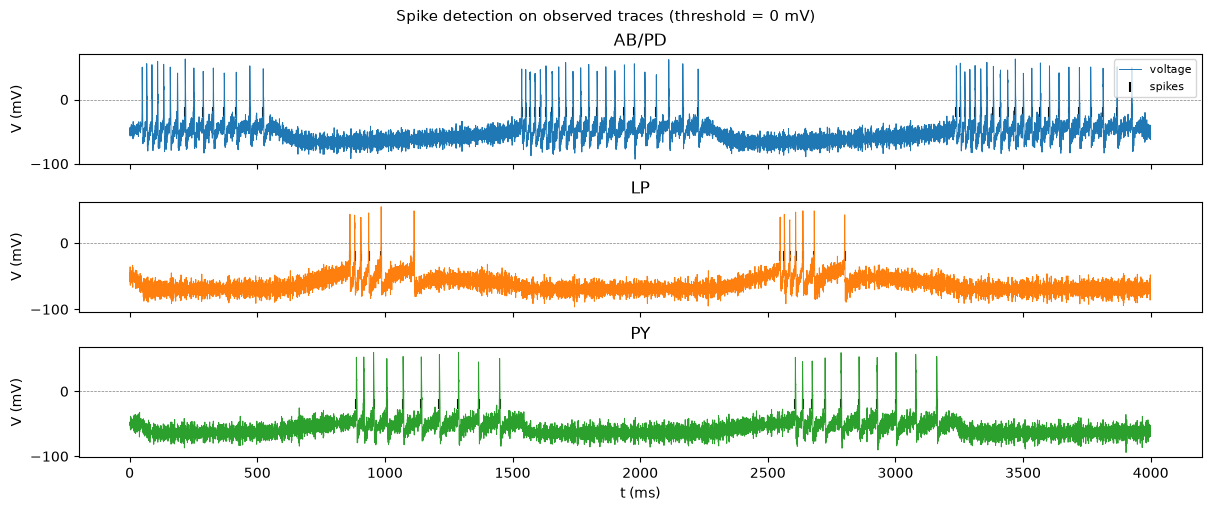

In [8]:
# Show spike & burst detection on the observation
fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True, layout="constrained")
neuron_names = ["AB/PD", "LP", "PY"]
colors = ["C0", "C1", "C2"]

for i, (name, col) in enumerate(zip(neuron_names, colors)):
    axs[i].plot(t_obs, v_obs[i], color=col, lw=0.7, label="voltage")
    spk = detect_spikes(v_obs[i], dt=dt_obs, threshold=0.0)
    spk = spk[spk > 200]
    axs[i].scatter(
        spk, np.full_like(spk, -20.0), marker="|", s=50, color="k", label="spikes"
    )
    axs[i].set_ylabel("V (mV)")
    axs[i].set_title(name)
    axs[i].axhline(0, color="gray", lw=0.5, ls="--")

axs[-1].set_xlabel("t (ms)")
axs[0].legend(fontsize=8)
fig.suptitle("Spike detection on observed traces (threshold = 0 mV)", fontsize=11)
plt.show()

In [9]:
# Verify summary statistics on the observation
TARGET_STATS = summary_statistics(v_obs, dt=dt_obs)
stats_obs_df = pd.DataFrame({"Statistic": STAT_LABELS, "Value": TARGET_STATS})
print(stats_obs_df.to_string(index=False))

         Statistic       Value
       period (ms) 1666.583333
  AB/PD duty cycle    0.387260
     LP duty cycle    0.149607
     PY duty cycle    0.324175
          LP phase    0.572504
          PY phase    0.599153
AB/PD spikes/burst   22.000000
   LP spikes/burst    6.500000
   PY spikes/burst   10.000000


## 5  Differential evolution optimisation
**Loss**: Weighted fractional error comparing 9 discrete biological features (network period, duty cycles, phase offsets, and spikes per burst) to the observation. Silent or non-bursting neurons yield `NaN` values, which are intercepted and assigned a scalar penalty

**Optimization Strategy**: Differential Evolution (Derivative-Free Optimization). Replaces gradient descent because the step functions inherent to spike detection are non-differentiable.

**Parameterisation**: $\log_{10}(\bar{g}) \in [-5, 1]$. Log-space ensures efficient evolutionary mutation and scaling across the 6-decade conductance range.

**Caveats**: Population-based evolutionary algorithms are massively compute-intensive. To make optimization tractable, the 4000 ms forward integration is strictly JIT-compiled via JAX (XLA) and isolated from the dynamic NumPy feature extraction.

# Below cells runs for 2 hours!

In [10]:
# 0. Restore network initialization
net_grad, param_keys_grad = build_network_for_grad()
T_MAX = 4000.0  # ms for full simulations


def compute_weighted_feature_distance(
    sim_stats: np.ndarray, target_stats: np.ndarray
) -> float:
    """
    Computes a normalized, weighted scalar distance between simulated and target features.

    Architecture:
    1. Normalization: Uses fractional error ((sim - obs) / obs) so that period (ms)
       and duty cycle (0-1) contribute equally to the loss.
    2. Missing Data Culling: Assigns a severe fixed penalty to NaN features to instantly
       kill silent or non-bursting network topologies in the evolutionary population.
    """
    # 1. Base Weights
    # In (STG) models, you often weight phase offsets (idx 4,5) higher than spike counts
    weights = np.array([1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 1.0, 1.0, 1.0])

    # 2. NaN Penalty
    nan_penalty = 10.0

    # Identify which features were successfully extracted
    valid_mask = ~np.isnan(sim_stats)

    # 3. Fractional Error Calculation
    fractional_error = np.zeros_like(sim_stats)

    # Only divide valid numbers to avoid Numpy ZeroDivision/NaN runtime warnings
    fractional_error[valid_mask] = (
        sim_stats[valid_mask] - target_stats[valid_mask]
    ) / target_stats[valid_mask]

    # 4. Apply Weights and Compute L2 Norm (Squared Error)
    squared_errors = weights * (fractional_error**2)

    # 5. Route Valid Errors and Penalties
    feature_costs = np.where(valid_mask, squared_errors, nan_penalty)

    return float(np.sum(feature_costs))


# 1. Isolate and JIT the expensive integration
@jax.jit
def simulate_fast(log10_g_flat):
    params = make_params_from_log10g(param_keys_grad, log10_g_flat)
    return jx.integrate(
        net_grad,
        params=params,
        t_max=T_MAX,  # 4000.0 ms
        delta_t=0.025,
    )


history_params = []
history_loss = []


# 2. The Loss Function (Standard Python/NumPy)
def feature_loss_fn(log10_g_flat):
    # Execute the blazing fast compiled XLA simulation
    v_sim_jax = simulate_fast(log10_g_flat)

    # Cast back to standard NumPy for dynamic feature extraction
    v_sim_np = np.array(v_sim_jax)

    # Extract discrete features
    sim_stats = summary_statistics(v_sim_np, dt=0.025, burn_in_ms=500.0)

    # Compute cost
    cost = compute_weighted_feature_distance(sim_stats, TARGET_STATS)

    # 4. Record the geometry of this evaluation
    history_params.append(log10_g_flat.copy())
    history_loss.append(cost)

    return cost


# 3. Optimization Setup
n_params = len(PRINZ_G_INIT_US)
bounds = [(-5.0, 1.0) for _ in range(n_params)]

print("=== Starting Differential Evolution Optimization ===")

# The very first evaluation will take ~5-10 seconds to compile XLA.
# Every subsequent evaluation will take milliseconds.
result = differential_evolution(
    feature_loss_fn,
    bounds,
    maxiter=50,
    popsize=5,
    disp=True,
    workers=1,  # STRICTLY 1 to avoid XLA deadlocks
)

print(f"  Final Feature Loss: {result.fun:.4f}")
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10**result.x]}')

# save all important objects
np.savez_compressed(
    "optimization_results.npz",
    params=np.array(history_params),
    losses=np.array(history_loss),
    param_names=np.array(
        param_keys_grad
    ),  # Ensures the names stay synced with the axes
)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
=== Starting Differential Evolution Optimization ===


differential_evolution step 1: f(x)= 0.2750177278087722


differential_evolution step 2: f(x)= 0.02599167385519928


differential_evolution step 3: f(x)= 0.02599167385519928


differential_evolution step 4: f(x)= 0.02599167385519928


...

differential_evolution step 47: f(x)= 0.0052441880295719225


differential_evolution step 48: f(x)= 0.0052441880295719225


differential_evolution step 49: f(x)= 0.0052441880295719225


differential_evolution step 50: f(x)= 0.0052441880295719225
Polishing solution with 'L-BFGS-B'


  Final Feature Loss: 0.0052
  g_opt (µS): ['1.8889', '0.0045', '0.0518', '0.0078', '0.0010', '0.0003', '0.0035']


### examine the results and result landscape

In [11]:
# Best parameters from the DE run.
# If the 2-hour optimisation cell above was just run, result.x is available;
# otherwise we fall back to the hardcoded result from a completed run
# (final feature loss = 0.0073, 50 iterations, 1793 function evaluations).
try:
    best_log10_g_de = np.array(result.x)
    print(f'Using live result  — loss: {result.fun:.6f}, iters: {result.nit}, evals: {result.nfev}')
except NameError:
    best_log10_g_de = np.array([0.25495598, -1.76788206, -1.28085388, -2.16560886, -3.13587851, -4.7167629, -3.36670664])
    print('Using hardcoded result — loss: 0.00730, iters: 50, evals: 1793')

g_best_de = 10.0 ** best_log10_g_de
print('\nBest DE conductances:')
for lbl, lg, g in zip(SYNAPSE_LABELS, best_log10_g_de, g_best_de):
    print(f'  {lbl:30s}  log10(g) = {lg:+.3f}   g = {g:.5f} µS')


Using hardcoded result — loss: 0.00730, iters: 50, evals: 1793

Best DE conductances:
  AB/PD→LP (Glut)                 log10(g) = +0.255   g = 1.79869 µS
  AB/PD→LP (Chol)                 log10(g) = -1.768   g = 0.01707 µS
  AB/PD→PY (Glut)                 log10(g) = -1.281   g = 0.05238 µS
  AB/PD→PY (Chol)                 log10(g) = -2.166   g = 0.00683 µS
  LP→AB/PD (Glut)                 log10(g) = -3.136   g = 0.00073 µS
  LP→PY (Glut)                    log10(g) = -4.717   g = 0.00002 µS
  PY→LP (Glut)                    log10(g) = -3.367   g = 0.00043 µS


In [12]:
# Best log10(g) from the completed DE run (hardcoded so the notebook is
# fully runnable without re-running the 2-hour optimisation cell above).
try:
    best_log10_g_de = np.array(result.x)   # use live result if available
except NameError:
    best_log10_g_de = np.array([0.25495598, -1.76788206, -1.28085388, -2.16560886, -3.13587851, -4.7167629, -3.36670664])

g_best_de = 10.0 ** best_log10_g_de
print('Best DE conductances (µS):')
for lbl, g in zip(SYNAPSE_LABELS, g_best_de):
    print(f'  {lbl:30s}: {g:.5f}')


Best DE conductances (µS):
  AB/PD→LP (Glut)               : 1.79869
  AB/PD→LP (Chol)               : 0.01707
  AB/PD→PY (Glut)               : 0.05238
  AB/PD→PY (Chol)               : 0.00683
  LP→AB/PD (Glut)               : 0.00073
  LP→PY (Glut)                  : 0.00002
  PY→LP (Glut)                  : 0.00043


Loaded 1793 evaluated points.


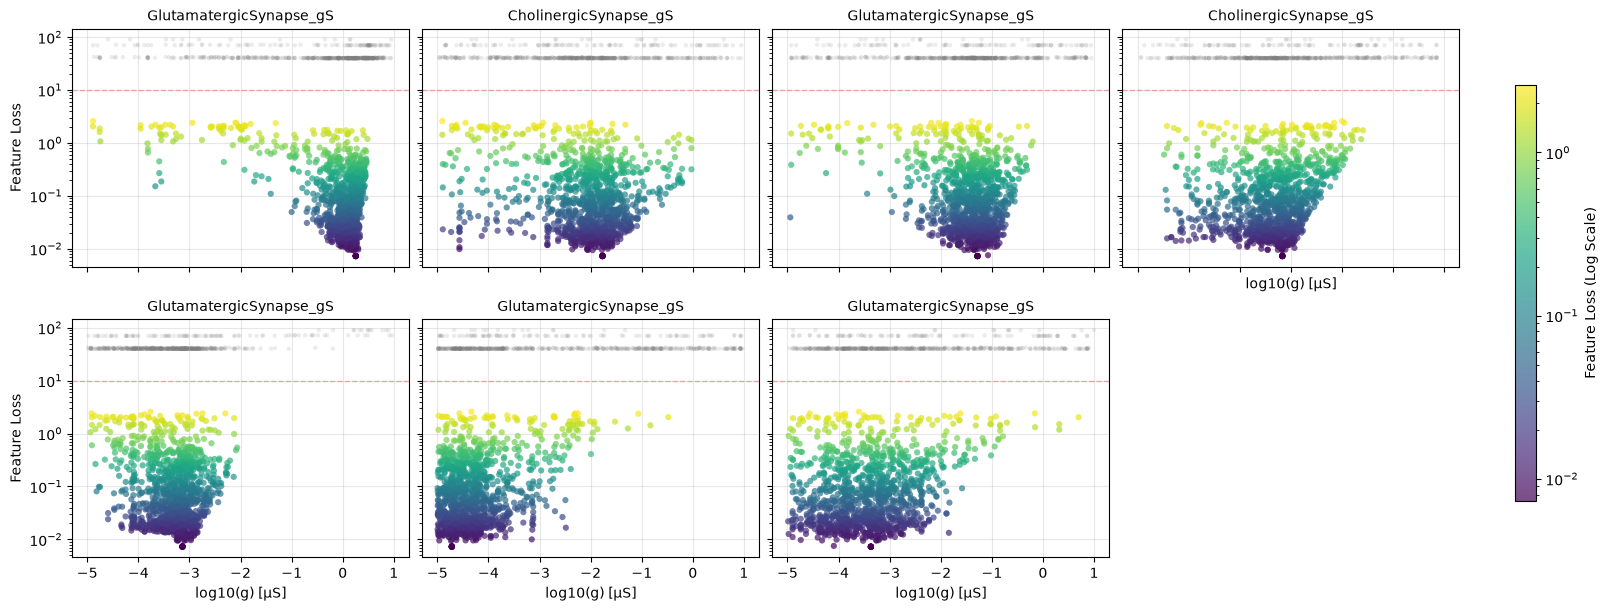

In [1]:
# Load the compressed archive
data = np.load("optimization_results.npz")

# Extract the arrays
loaded_params = data["params"]
loaded_losses = data["losses"]
loaded_names = data["param_names"]

print(f"Loaded {len(loaded_losses)} evaluated points.")

# Draw the landscape
plot_loss_landscape(loaded_params, loaded_losses, loaded_names)

### Convergence diagnostics

Two additional views of the same `optimization_results.npz` archive: the loss
trajectory across all function evaluations (showing whether/when DE converges),
and a pairwise view of every evaluated parameter combination (showing whether the
population collapses onto a compact, bursting region or stays spread out).

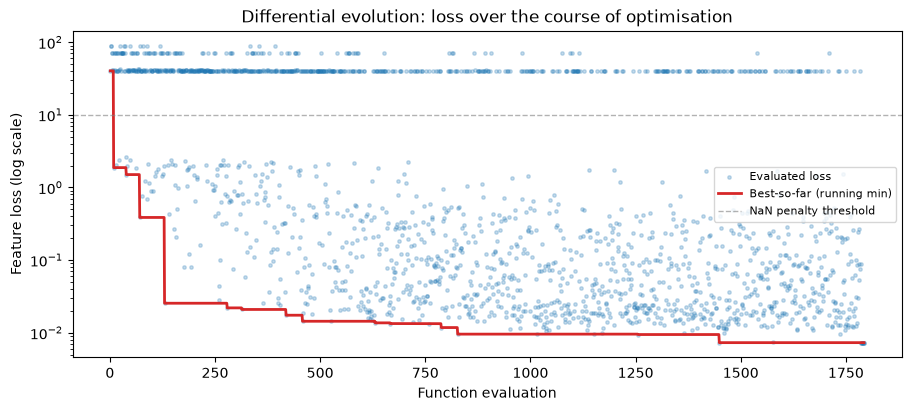

Best loss reached: 0.0073 at evaluation 1449/1793


In [2]:
# Loss value over the course of the optimisation (evaluation order).
# DE evaluates popsize x (maxiter+1) candidates per generation; the running
# minimum traces out the convergence curve regardless of per-candidate noise.
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
evals = np.arange(1, len(loaded_losses) + 1)
running_min = np.minimum.accumulate(loaded_losses)

ax.scatter(evals, loaded_losses, s=6, alpha=0.25, color='C0', label='Evaluated loss')
ax.plot(evals, running_min, color='C3', lw=2, label='Best-so-far (running min)')
ax.axhline(10.0, color='gray', ls='--', lw=1, alpha=0.6, label='NaN penalty threshold')
ax.set_yscale('log')
ax.set_xlabel('Function evaluation')
ax.set_ylabel('Feature loss (log scale)')
ax.set_title('Differential evolution: loss over the course of optimisation')
ax.legend(fontsize=8)
fig.savefig('fig_de_loss_over_time.pdf', bbox_inches='tight')
plt.show()

print(f'Best loss reached: {running_min[-1]:.4f} '
      f'at evaluation {int(np.argmin(loaded_losses)) + 1}/{len(loaded_losses)}')


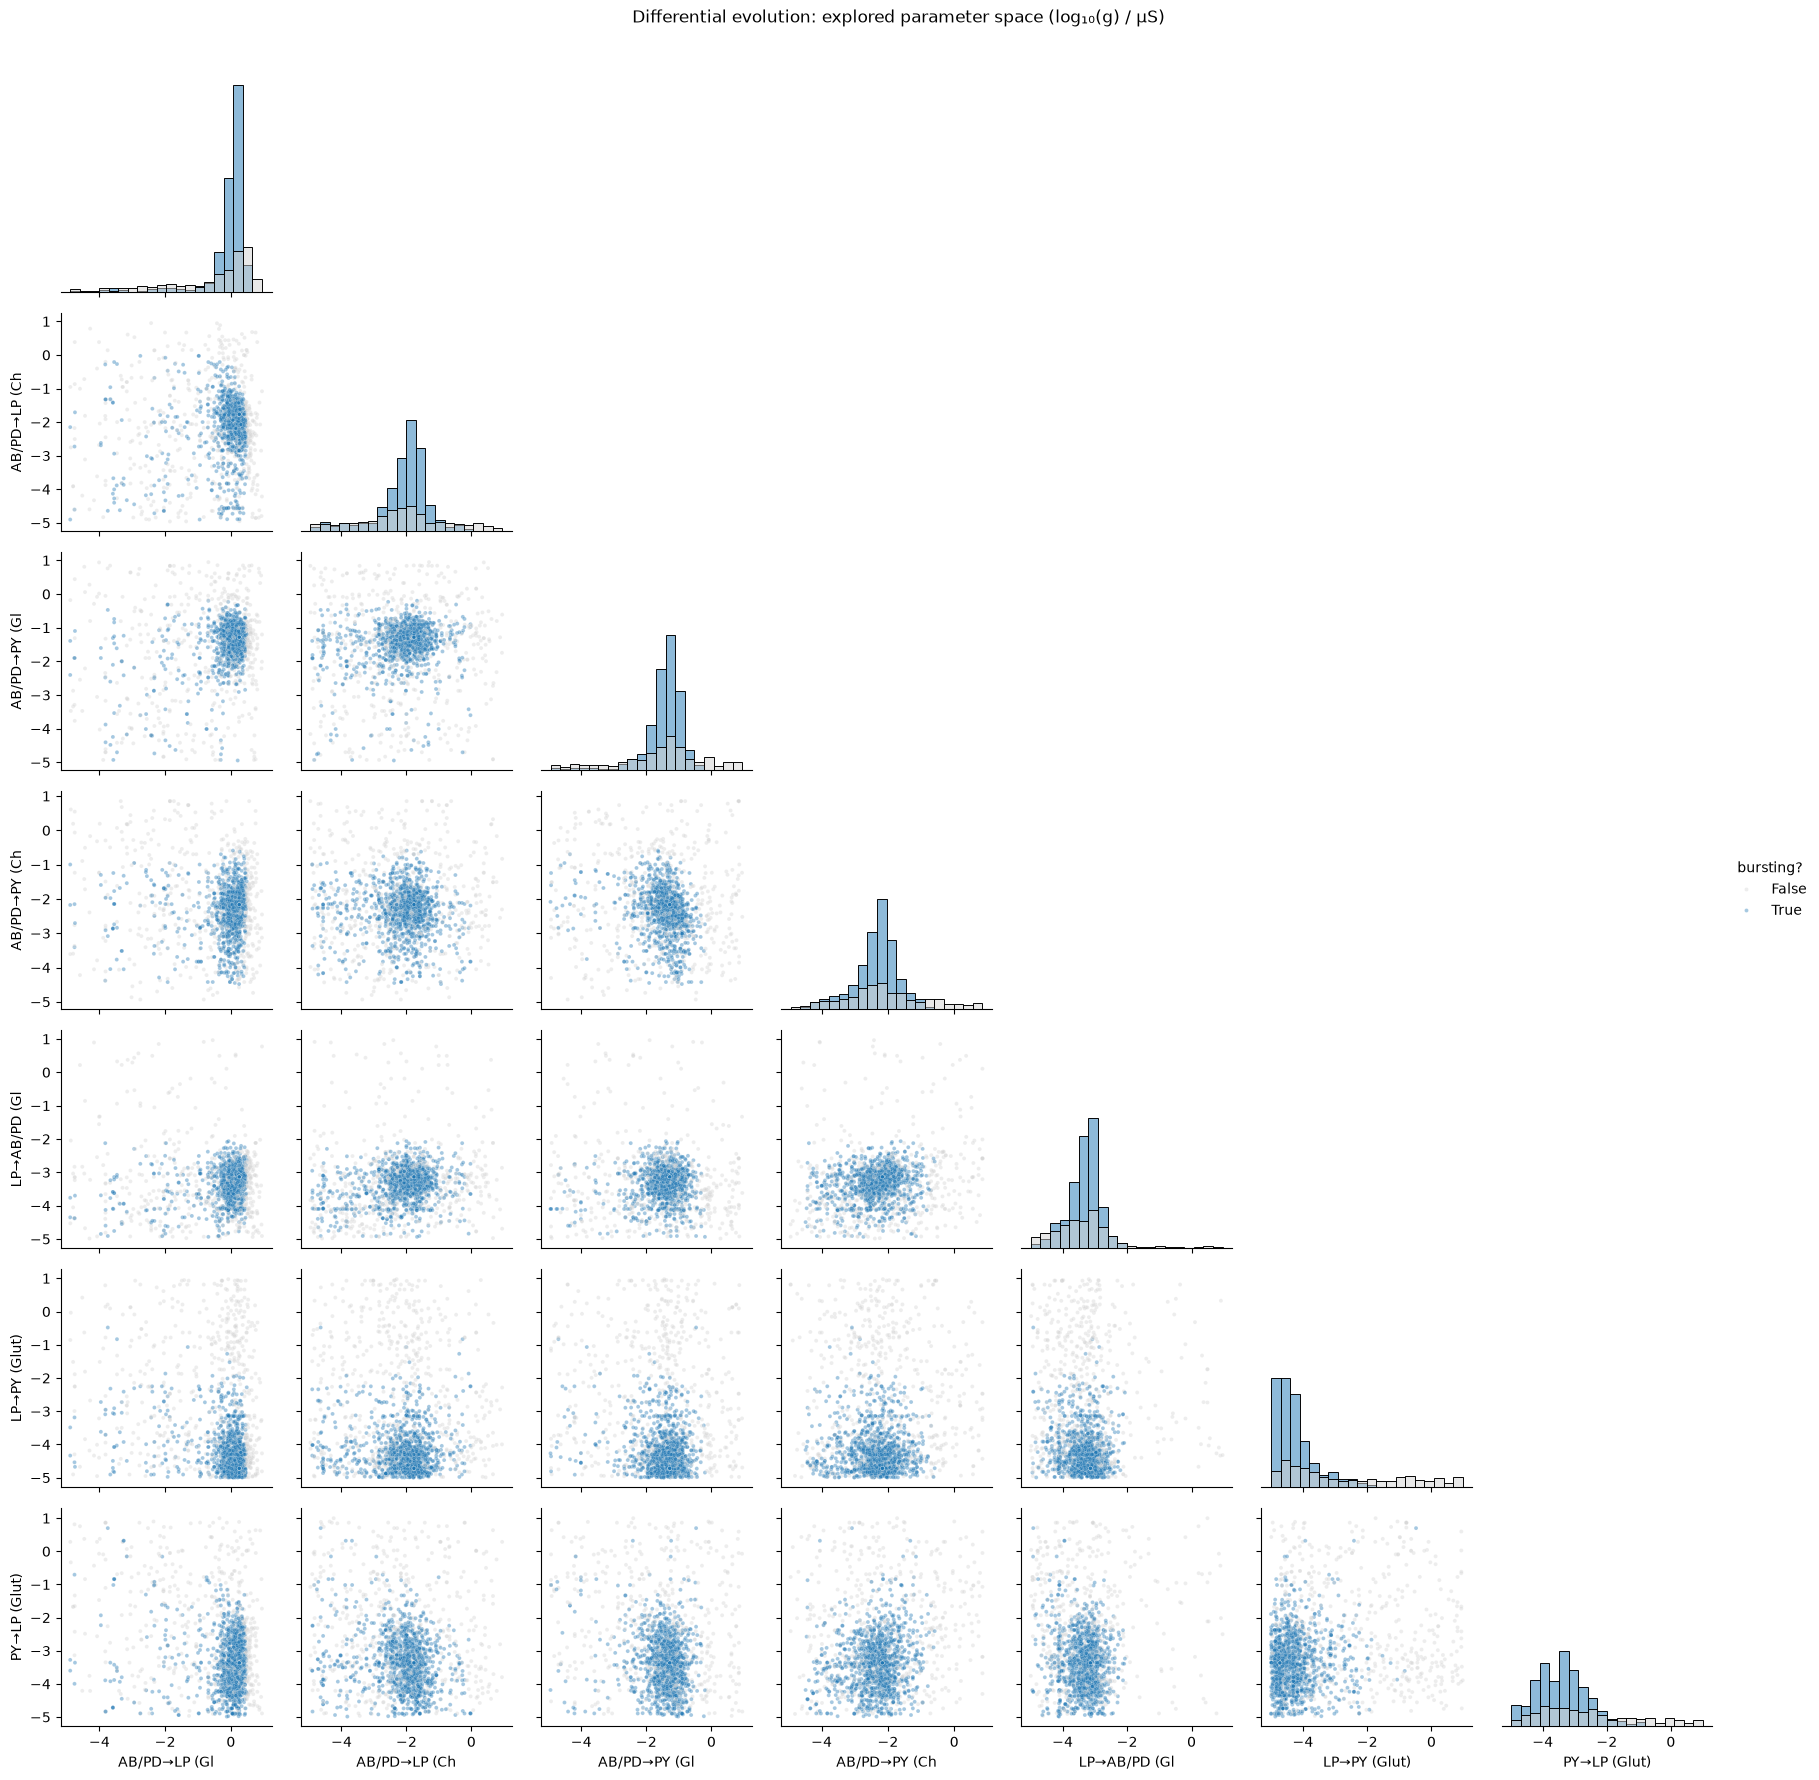

In [3]:
# Pairwise parameter plot for the DE search: which conductance combinations
# were explored, and did the population converge to a compact bursting region?
import seaborn as sns

de_param_cols = [lbl[:12] for lbl in SYNAPSE_LABELS]
df_de_params = pd.DataFrame(loaded_params, columns=de_param_cols)
df_de_params['bursting'] = loaded_losses < 10.0  # below the NaN-penalty threshold

g_de = sns.PairGrid(
    df_de_params, hue='bursting', vars=de_param_cols,
    palette={True: 'C0', False: 'lightgray'}, corner=True,
)
g_de.map_diag(sns.histplot, bins=20)
g_de.map_lower(sns.scatterplot, s=8, alpha=0.4)
g_de.add_legend(title='bursting?')
g_de.fig.suptitle('Differential evolution: explored parameter space (log₁₀(g) / µS)', y=1.02)
g_de.fig.savefig('fig_de_pairplot.pdf', bbox_inches='tight')
plt.show()


In [16]:
# Simulate the best DE solution over the full 4 s recording
t_plot, v_best_de = simulate(g_best_de, t_max=4000.0)


Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


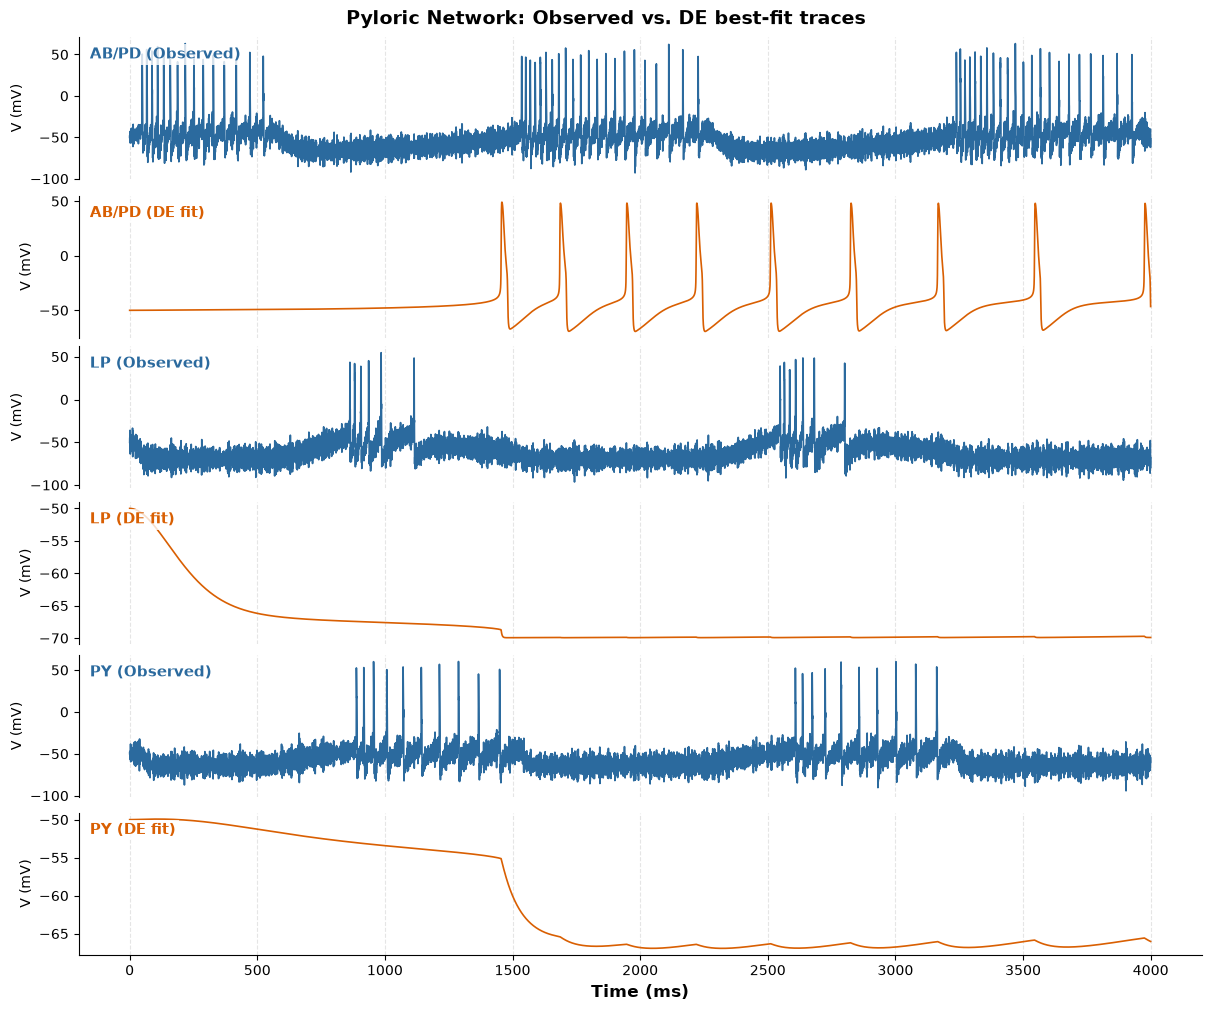

In [17]:
# Paired subplot: observed (blue) directly above simulated (orange) for each neuron.
# This makes phase alignment errors immediately visible.
fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True, layout='constrained')

cell_names = ['AB/PD', 'LP', 'PY']
colors = {'obs': '#2b6a9e', 'sim': '#d95f02'}

for i, name in enumerate(cell_names):
    ax_obs = axs[i * 2]       # even rows: observed
    ax_sim = axs[i * 2 + 1]   # odd  rows: simulated

    ax_obs.plot(t_obs, v_obs[i], color=colors['obs'], lw=1.2)
    ax_obs.set_ylabel('V (mV)', fontsize=10)
    ax_obs.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_obs.tick_params(axis='x', bottom=False)
    ax_obs.text(0.01, 0.85, f'{name} (Observed)', transform=ax_obs.transAxes,
               fontsize=11, fontweight='bold', color=colors['obs'],
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
    ax_obs.grid(True, axis='x', color='gray', alpha=0.2, linestyle='--')

    # Clip simulation to observation length (sim has one extra timestep)
    n = min(len(t_obs), v_best_de.shape[1])
    ax_sim.plot(t_obs[:n], v_best_de[i, :n], color=colors['sim'], lw=1.2)
    ax_sim.set_ylabel('V (mV)', fontsize=10)
    if i < 2:
        ax_sim.spines[['top', 'right', 'bottom']].set_visible(False)
        ax_sim.tick_params(axis='x', bottom=False)
    else:
        ax_sim.spines[['top', 'right']].set_visible(False)
    ax_sim.text(0.01, 0.85, f'{name} (DE fit)', transform=ax_sim.transAxes,
               fontsize=11, fontweight='bold', color=colors['sim'],
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
    ax_sim.grid(True, axis='x', color='gray', alpha=0.2, linestyle='--')

axs[-1].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
fig.suptitle('Pyloric Network: Observed vs. DE best-fit traces', fontsize=14, fontweight='bold')
plt.savefig('fig_de_fit.pdf', bbox_inches='tight')
plt.show()


## 5b  Gradient descent — empirical comparison

Section 5 explained *why* we expected gradient descent to underperform differential
evolution (non-differentiable features, phase-sensitive MSE). Here we confirm that
empirically with a real run, reusing the differentiable network `net_grad` /
`param_keys_grad` already built for the DE loss above.

**Loss**: MSE between the simulated and observed voltage, subsampled to the
observation's dt = 0.25 ms. To keep each gradient step affordable we optimise
against the first **2 s** of the recording (`T_GD`) rather than the full 4 s, and use
Jaxley's `checkpoint_lengths` to bound the memory cost of backpropagating through
the ODE solve.  
**Optimiser**: Adam (lr = 0.02) with global gradient-norm clipping, in log₁₀-space.  
**Restarts**: 3 — the Prinz-inspired init used for DE, plus two random initialisations
— since a single run only reveals one local optimum of a possibly multi-modal loss.

In [18]:
import time as _time

# Re-uses net_grad / param_keys_grad from the DE section above (cell '0. Restore
# network initialization') — no need to rebuild the network a third time.
v_obs_jax = jnp.array(v_obs)
T_GD = 2000.0   # ms used for the GD loss (full 4 s reserved for verification)

gd_loss_and_grad = build_gd_loss_and_grad(
    net_grad, param_keys_grad, v_obs_jax, t_gd=T_GD, subsample=10
)

# JIT warmup (first call compiles; empirically ~2.5 s thereafter per step)
t0 = _time.time()
_loss0, _ = gd_loss_and_grad(jnp.log10(jnp.array(PRINZ_G_INIT_US)))
print(f'JIT compiled in {_time.time() - t0:.1f} s. Loss at Prinz init: {float(_loss0):.2f}')
print('Each gradient step ~2.5 s; 200 steps x 3 restarts ~ 25 min.')


JIT compiled in 3.0 s. Loss at Prinz init: 351.62
Each gradient step ~2.5 s; 200 steps x 3 restarts ~ 25 min.


In [19]:
print('=== Restart 1: Prinz bursting init ===')
log10_init_1 = jnp.log10(jnp.array(PRINZ_G_INIT_US))
log10_opt_1, hist_1, params_hist_1 = run_gradient_descent(gd_loss_and_grad, log10_init_1)
print(f'  Final loss: {hist_1[-1]:.2f}')
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10 ** np.array(log10_opt_1)]}')


=== Restart 1: Prinz bursting init ===


  step   0: loss = 351.62


  step  50: loss = 336.37


  step 100: loss = 287.72


  step 150: loss = 322.25


  Final loss: 256.76
  g_opt (µS): ['0.1028', '0.1470', '0.2078', '0.0338', '0.0881', '0.0136', '0.1371']


In [20]:
rng_gd = np.random.default_rng(42)
log10_init_2 = jnp.array(rng_gd.uniform(-2.5, -0.5, size=7))
print('=== Restart 2: random init ===')
log10_opt_2, hist_2, params_hist_2 = run_gradient_descent(gd_loss_and_grad, log10_init_2)
print(f'  Final loss: {hist_2[-1]:.2f}')
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10 ** np.array(log10_opt_2)]}')


=== Restart 2: random init ===


  step   0: loss = 314.55


  step  50: loss = 302.34


  step 100: loss = 287.52


  step 150: loss = 264.08


  Final loss: 248.27
  g_opt (µS): ['0.1989', '0.0228', '0.1913', '0.0319', '0.0083', '0.0179', '0.1616']


In [21]:
log10_init_3 = jnp.array(rng_gd.uniform(-2.5, -0.5, size=7))
print('=== Restart 3: random init ===')
log10_opt_3, hist_3, params_hist_3 = run_gradient_descent(gd_loss_and_grad, log10_init_3)
print(f'  Final loss: {hist_3[-1]:.2f}')
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10 ** np.array(log10_opt_3)]}')


=== Restart 3: random init ===


  step   0: loss = 317.03


  step  50: loss = 300.29


  step 100: loss = 308.22


  step 150: loss = 295.53


  Final loss: 322.95
  g_opt (µS): ['0.3501', '0.0178', '0.0089', '0.0070', '0.1787', '0.0352', '0.1966']


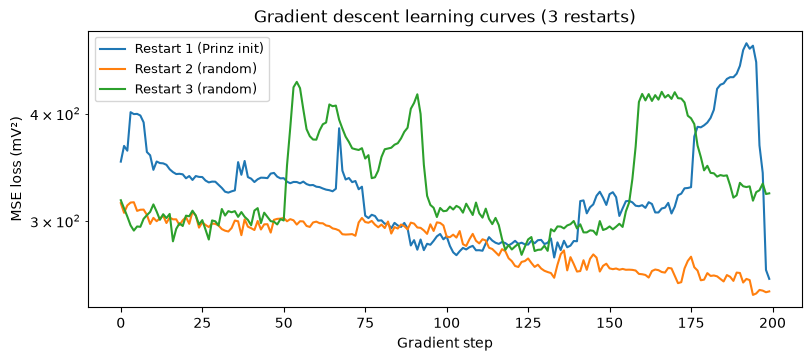

In [22]:
# Learning curves: does each restart converge, and to what loss level?
fig, ax = plt.subplots(figsize=(8, 3.5), layout='constrained')
ax.semilogy(hist_1, label='Restart 1 (Prinz init)')
ax.semilogy(hist_2, label='Restart 2 (random)')
ax.semilogy(hist_3, label='Restart 3 (random)')
ax.set_xlabel('Gradient step')
ax.set_ylabel('MSE loss (mV²)')
ax.set_title('Gradient descent learning curves (3 restarts)')
ax.legend(fontsize=9)
fig.savefig('fig_gd_learning_curves.pdf', bbox_inches='tight')
plt.show()


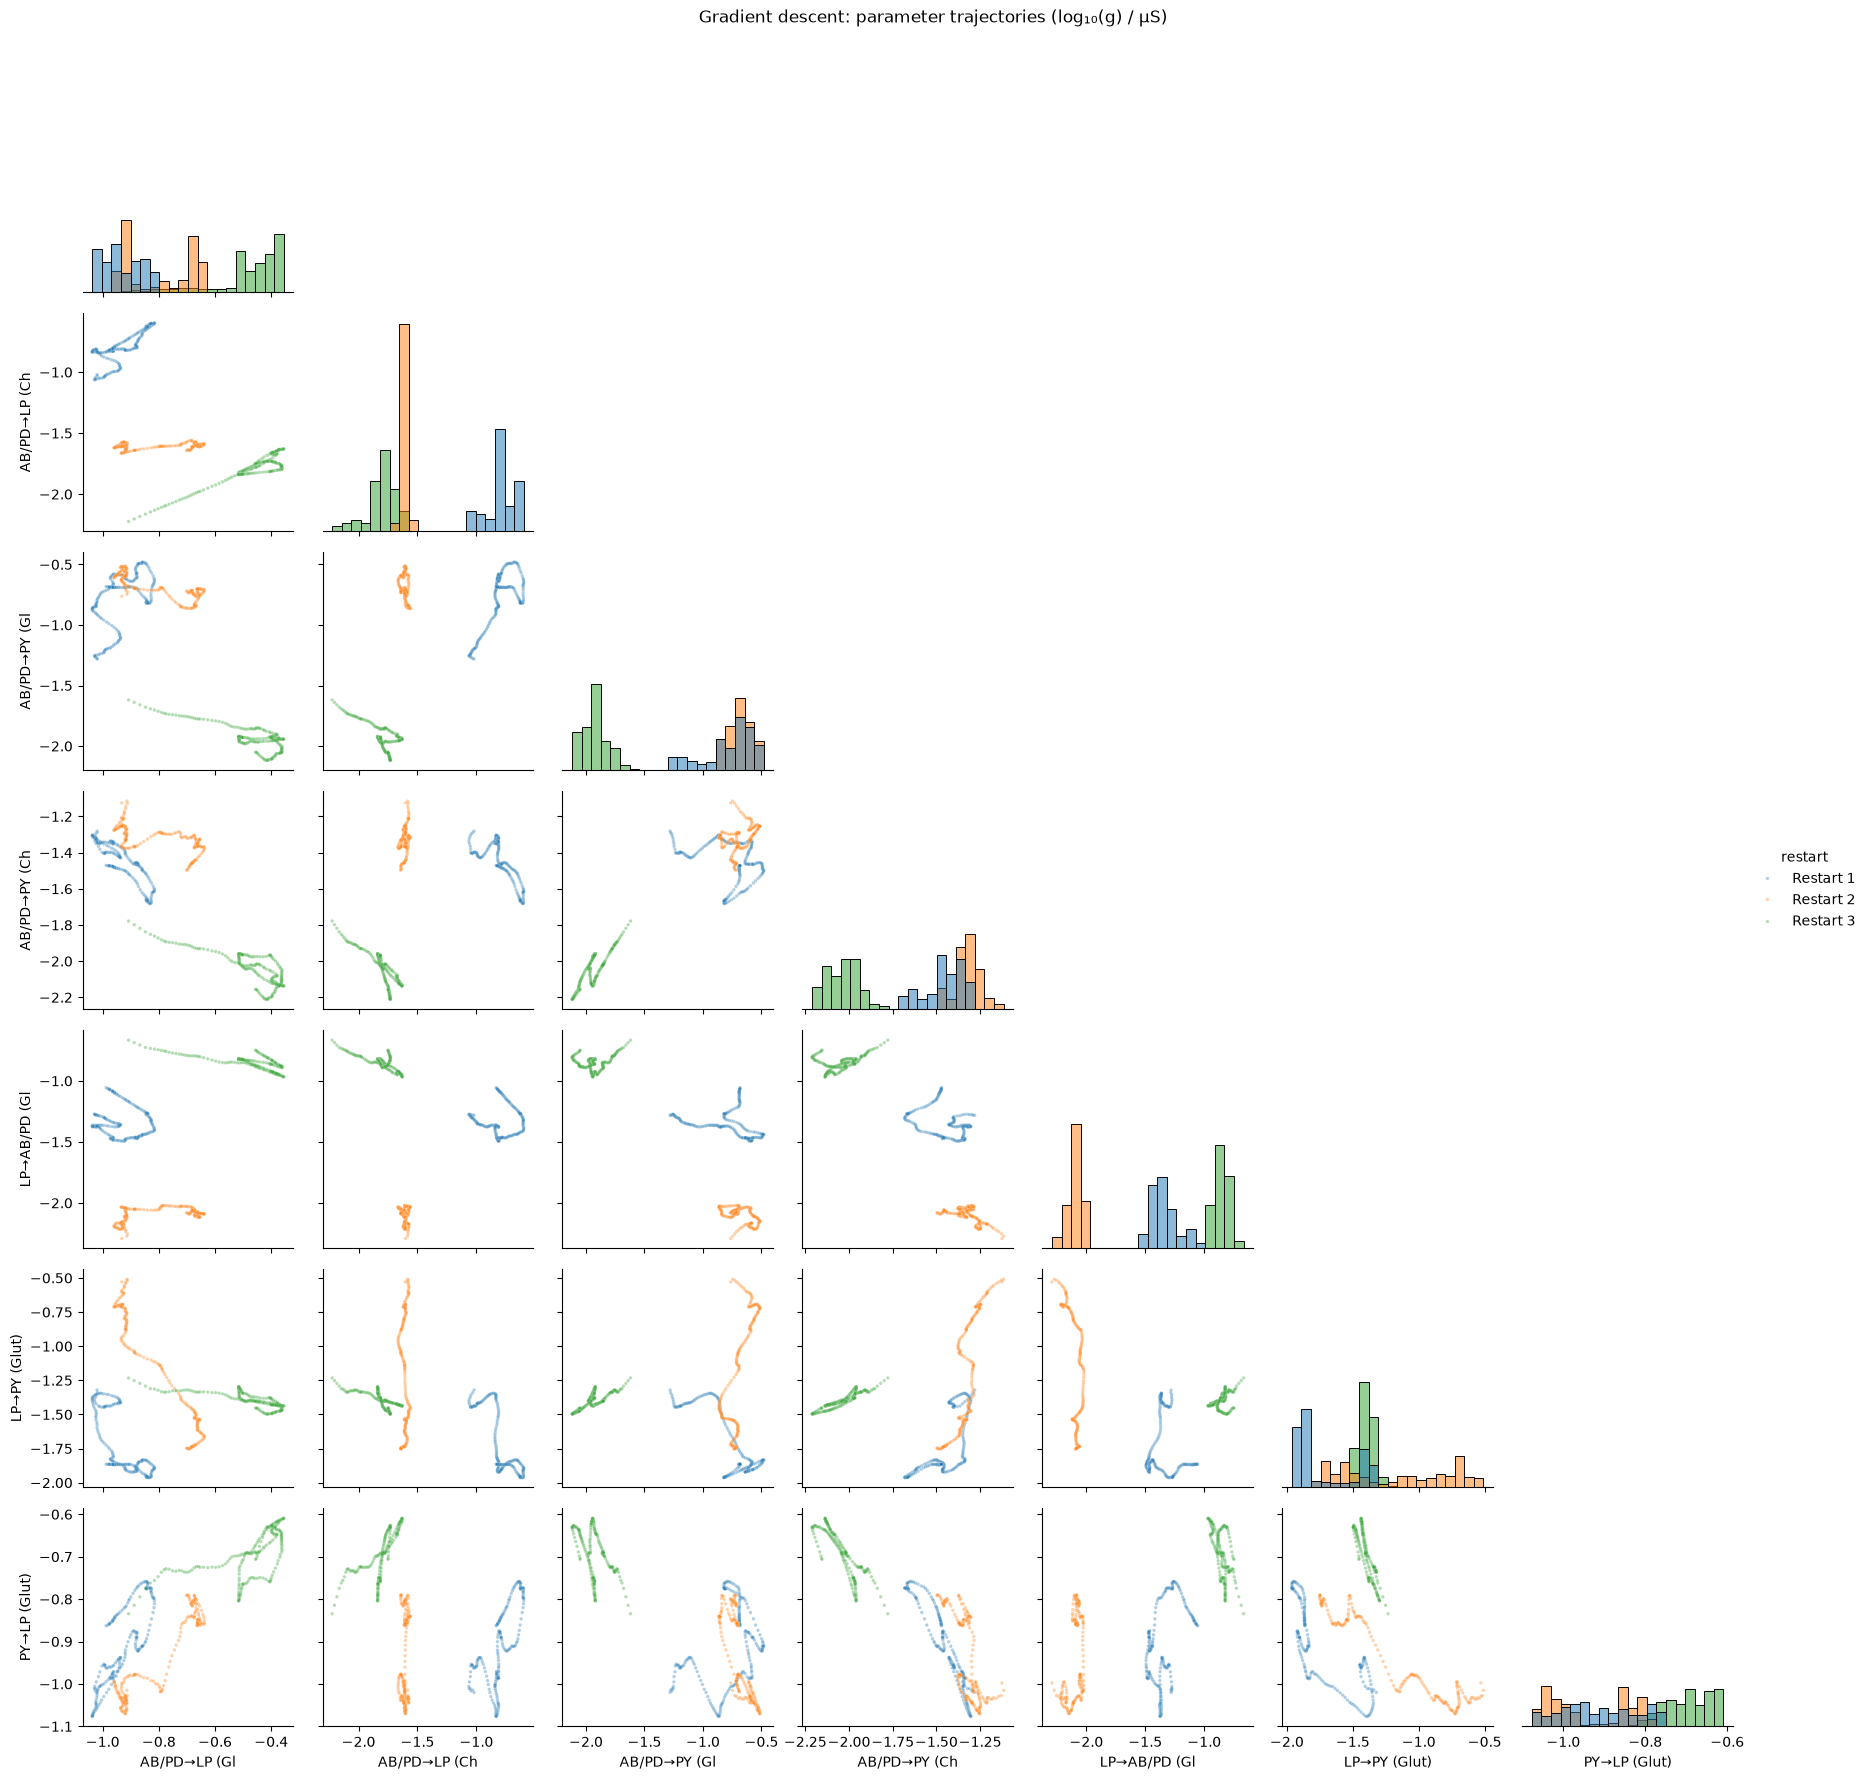

In [23]:
# Pairwise parameter plot: the full log10(g) trajectory of all 3 restarts
# (200 steps each). Restarts landing in different, non-overlapping clouds is
# direct evidence of a multi-modal loss landscape — exactly what motivated
# using differential evolution's population-based global search instead.
gd_param_cols = [lbl[:12] for lbl in SYNAPSE_LABELS]
df_gd_traj = pd.concat([
    pd.DataFrame(params_hist_1, columns=gd_param_cols).assign(restart='Restart 1'),
    pd.DataFrame(params_hist_2, columns=gd_param_cols).assign(restart='Restart 2'),
    pd.DataFrame(params_hist_3, columns=gd_param_cols).assign(restart='Restart 3'),
], ignore_index=True)

g_gd = sns.PairGrid(df_gd_traj, hue='restart', vars=gd_param_cols, corner=True)
g_gd.map_diag(sns.histplot, bins=20)
g_gd.map_lower(sns.scatterplot, s=6, alpha=0.35)
g_gd.add_legend(title='restart')
g_gd.fig.suptitle('Gradient descent: parameter trajectories (log₁₀(g) / µS)', y=1.02)
g_gd.fig.savefig('fig_gd_pairplot.pdf', bbox_inches='tight')
plt.show()


Best restart: Restart 2, loss=248.27
Optimised conductances (µS):
  AB/PD→LP (Glut)               : 0.19888
  AB/PD→LP (Chol)               : 0.02275
  AB/PD→PY (Glut)               : 0.19133
  AB/PD→PY (Chol)               : 0.03186
  LP→AB/PD (Glut)               : 0.00832
  LP→PY (Glut)                  : 0.01792
  PY→LP (Glut)                  : 0.16155


Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7



Summary statistics comparison:
         Statistic    Observed  GD best-fit
       period (ms) 1666.583333          NaN
  AB/PD duty cycle    0.387260     0.311677
     LP duty cycle    0.149607     0.116311
     PY duty cycle    0.324175          NaN
          LP phase    0.572504     0.524668
          PY phase    0.599153          NaN
AB/PD spikes/burst   22.000000    19.000000
   LP spikes/burst    6.500000     5.000000
   PY spikes/burst   10.000000          NaN


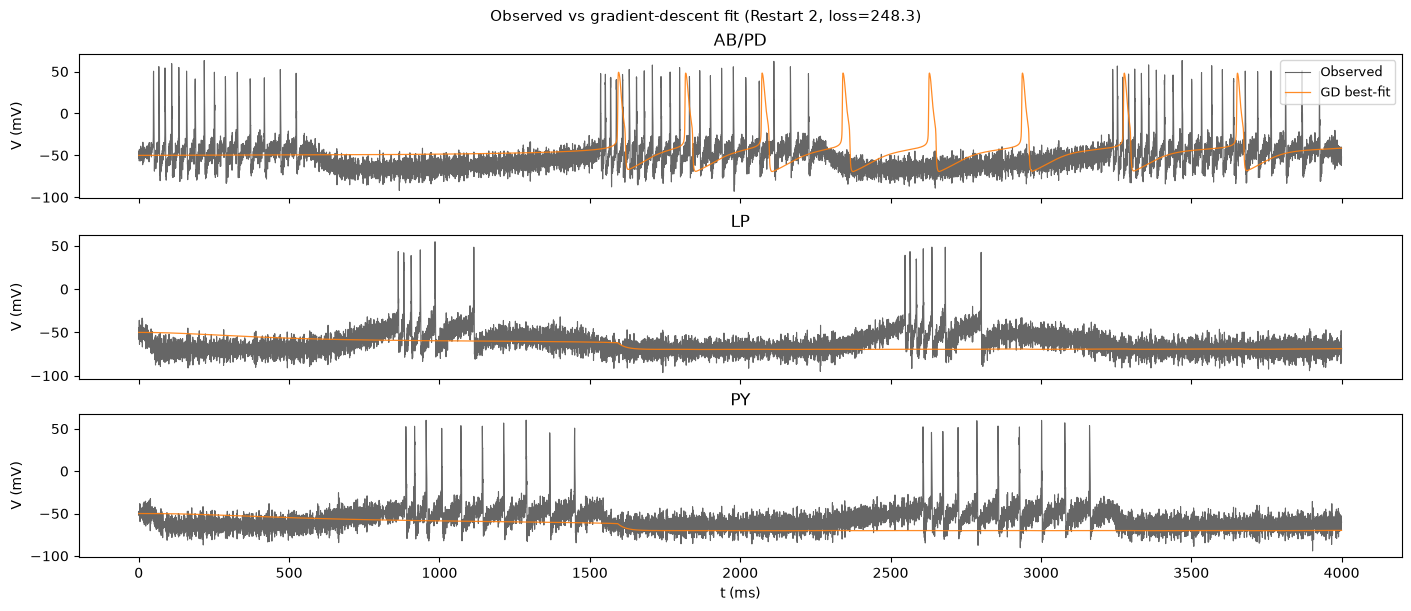

In [24]:
# Best restart: simulate the full 4 s recording and compare against observation
all_gd_results = [
    (hist_1[-1], log10_opt_1, 'Restart 1'),
    (hist_2[-1], log10_opt_2, 'Restart 2'),
    (hist_3[-1], log10_opt_3, 'Restart 3'),
]
best_gd_loss, log10_opt_best_gd, best_gd_label = sorted(all_gd_results, key=lambda r: r[0])[0]
g_opt_best_gd = 10.0 ** np.array(log10_opt_best_gd)

print(f'Best restart: {best_gd_label}, loss={best_gd_loss:.2f}')
print('Optimised conductances (µS):')
for lbl, g in zip(SYNAPSE_LABELS, g_opt_best_gd):
    print(f'  {lbl:30s}: {g:.5f}')

_, v_gd_best = simulate(g_opt_best_gd, t_max=4000.0, dt=0.025)
stats_gd_best = summary_statistics(v_gd_best, dt=0.025)
df_gd_cmp = pd.DataFrame({
    'Statistic': STAT_LABELS, 'Observed': TARGET_STATS, 'GD best-fit': stats_gd_best,
})
print('\nSummary statistics comparison:')
print(df_gd_cmp.to_string(index=False))

fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, layout='constrained')
n_gd = min(len(t_obs), v_gd_best.shape[1])
for i, name in enumerate(['AB/PD', 'LP', 'PY']):
    axs[i].plot(t_obs, v_obs[i], color='k', lw=0.8, alpha=0.6, label='Observed')
    axs[i].plot(t_obs[:n_gd], v_gd_best[i, :n_gd], color='C1', lw=0.9, alpha=0.9, label='GD best-fit')
    axs[i].set_ylabel('V (mV)')
    axs[i].set_title(name)
axs[-1].set_xlabel('t (ms)')
axs[0].legend(fontsize=9)
fig.suptitle(f'Observed vs gradient-descent fit ({best_gd_label}, loss={best_gd_loss:.1f})', fontsize=11)
fig.savefig('fig_gd_fit.pdf', bbox_inches='tight')
plt.show()


## 6  Simulation-based inference (SNPE)

Differential evolution gives a point estimate but cannot characterise **uncertainty**
or **degeneracy** — the question of whether multiple distinct parameter sets can
produce the same rhythm. We address this with Sequential Neural Posterior Estimation
(SNPE-C / APT) from the `sbi` package, which learns the full posterior
p(θ | x_obs) over all 7 conductances at once.

**Prior**: Log-uniform over [10⁻⁵, 10] µS → Uniform(−5, 1) in log₁₀-space.  
**Simulator**: 7 log₁₀-conductances → 9 summary statistics.  
**Speed**: the naive simulator (used for DE above) rebuilds the whole Jaxley network
from scratch on every call and never JIT-compiles `jx.integrate`, costing ~2 s/simulation.
For SNPE we need far more simulations, so we build the network **once** and wrap
`jx.integrate` in `jax.jit` + `jax.vmap` to integrate a whole batch of parameter sets
in a single compiled XLA call. Measured speedup: ~0.08–0.1 s/simulation at batch size 50
— roughly a **20× speedup**.

**Strategy**: sample from the prior in batches of 50 until **1,000 valid** (bursting)
simulations are collected, capped at 15,000 total. `sbi`'s rule of thumb is ≥10,000
training simulations for a reliably-trained normalising flow; at our ~10% validity
rate that means ~1,000 valid ones. With the batched simulator this takes ~15–20 min,
instead of the >5 h a sequential, non-JIT'd simulator would need for the same budget.

In [25]:
import torch
from sbi import utils as sbi_utils
from sbi import inference as sbi_inference

# Log-uniform prior over the 7 synaptic conductances
prior_low  = torch.tensor([-5.0] * 7, dtype=torch.float32)
prior_high = torch.tensor([ 1.0] * 7, dtype=torch.float32)
prior = sbi_utils.BoxUniform(low=prior_low, high=prior_high)

# Observation as a summary-statistic vector (same 9-feature format the simulator returns)
x_obs_tensor = torch.tensor(TARGET_STATS.astype(np.float32)).unsqueeze(0)
print('Observation summary statistics used as SNPE target:')
for lbl, v_ in zip(STAT_LABELS, TARGET_STATS):
    print(f'  {lbl:25s}: {v_:.3f}')


Observation summary statistics used as SNPE target:
  period (ms)              : 1666.583
  AB/PD duty cycle         : 0.387
  LP duty cycle            : 0.150
  PY duty cycle            : 0.324
  LP phase                 : 0.573
  PY phase                 : 0.599
  AB/PD spikes/burst       : 22.000
  LP spikes/burst          : 6.500
  PY spikes/burst          : 10.000


In [26]:
import time as _time

# Build the JIT-compiled, vmapped batch simulator ONCE and reuse it for every
# batch below. This sidesteps the two costs that dominate the naive per-sample
# path used for DE: rebuilding the whole Jaxley network from scratch on every
# call (~0.5-1 s), and re-tracing `jx.integrate` (no JIT cache reuse).
sim_batch_fn, param_keys_sbi = build_batched_simulator(t_max=4000.0, dt=0.025)

# Sanity check: batch of 4 copies of the Prinz init — should return finite stats
_test_batch = np.tile(np.log10(PRINZ_G_INIT_US), (4, 1))
t0 = _time.time()
_test_v = np.array(sim_batch_fn(jnp.array(_test_batch)))
print(f'Batch simulator compiled + ran in {_time.time() - t0:.2f} s '
      f'for a batch of {_test_v.shape[0]} (output shape {_test_v.shape})')
_test_stats = summary_statistics_batch(_test_v, dt=0.025)
print('All finite (bursting):', not np.isnan(_test_stats).any())


Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


Batch simulator compiled + ran in 2.21 s for a batch of 4 (output shape (4, 3, 160001))
All finite (bursting): False


In [27]:
# ── Sample from the prior in batches, using the JIT+vmap simulator ──────────
# Only ~10% of log-uniform prior samples produce rhythmic bursting on all three
# neurons. `sbi`'s rule of thumb is >=10,000 training simulations for a reliably
# trained normalising flow; at our ~10% validity rate that means ~1,000 valid.
# The batched simulator makes this tractable: ~0.08-0.1 s/sim (vs ~2 s/sim
# sequential) -> ~15-20 min for 10,000+ simulations, instead of several hours.
MIN_VALID_TARGET = 1000
MAX_SIM = 15000
BATCH_SIZE = 50

theta_list, x_list = [], []
n_valid = 0
n_total = 0
t_start = _time.time()

while n_valid < MIN_VALID_TARGET and n_total < MAX_SIM:
    batch_theta = prior.sample((BATCH_SIZE,))
    log10_g_batch = batch_theta.numpy().astype(np.float64)
    v_batch = np.array(sim_batch_fn(jnp.array(log10_g_batch)))
    stats_batch = summary_statistics_batch(v_batch, dt=0.025)

    theta_list.append(batch_theta)
    x_list.append(torch.tensor(stats_batch))
    n_total += BATCH_SIZE
    n_valid += int((~np.isnan(stats_batch).any(axis=1)).sum())

    elapsed = _time.time() - t_start
    rate = n_total / max(elapsed, 1e-9)
    remaining = max(MIN_VALID_TARGET - n_valid, 0) / max(n_valid / n_total, 1e-9)
    eta = remaining / max(rate, 1e-9)
    print(f'  {n_total} simulated, {n_valid} valid ({100*n_valid/n_total:.1f}%)  '
          f'[{elapsed:.0f}s elapsed, ETA: {eta:.0f} s]')

theta_samples = torch.cat(theta_list, dim=0)
x_train = torch.cat(x_list, dim=0)
print(f'\nDone in {_time.time() - t_start:.0f} s. '
      f'{n_valid}/{n_total} valid ({100*n_valid/n_total:.1f}%)')


  50 simulated, 4 valid (8.0%)  [5s elapsed, ETA: 1265 s]


  100 simulated, 9 valid (9.0%)  [9s elapsed, ETA: 1007 s]


  150 simulated, 10 valid (6.7%)  [13s elapsed, ETA: 1301 s]


  200 simulated, 14 valid (7.0%)  [17s elapsed, ETA: 1204 s]


  250 simulated, 18 valid (7.2%)  [21s elapsed, ETA: 1149 s]


...

  10650 simulated, 981 valid (9.2%)  [848s elapsed, ETA: 16 s]


  10700 simulated, 987 valid (9.2%)  [852s elapsed, ETA: 11 s]


  10750 simulated, 994 valid (9.2%)  [856s elapsed, ETA: 5 s]


  10800 simulated, 997 valid (9.2%)  [860s elapsed, ETA: 3 s]


  10850 simulated, 1001 valid (9.2%)  [864s elapsed, ETA: 0 s]

Done in 864 s. 1001/10850 valid (9.2%)


In [28]:
# ── Filter NaN rows (non-bursting) and train SNPE ────────────────────────────
valid_mask  = ~torch.isnan(x_train).any(dim=1)
theta_valid = theta_samples[valid_mask]
x_valid     = x_train[valid_mask]
print(f'Training SNPE on {valid_mask.sum()} valid simulations...')

inferrer = sbi_inference.SNPE(prior=prior)
inferrer.append_simulations(theta_valid, x_valid)
density_estimator = inferrer.train()
posterior = inferrer.build_posterior(density_estimator)
print('SNPE training complete.')


Training SNPE on 1001 valid simulations...


 Training neural network. Epochs trained: 14

 Training neural network. Epochs trained: 28

 Training neural network. Epochs trained: 41

 Training neural network. Epochs trained: 55

...

 Training neural network. Epochs trained: 152

 Training neural network. Epochs trained: 166

 Training neural network. Epochs trained: 180

 Training neural network. Epochs trained: 194

 Neural network successfully converged after 202 epochs.SNPE training complete.


In [29]:
# Draw samples from the learned posterior p(θ | x_obs)
N_POSTERIOR = 2000
posterior_samples = posterior.sample((N_POSTERIOR,), x=x_obs_tensor)
ps_np = posterior_samples.numpy()           # (N_POSTERIOR, 7) in log10(µS)
g_posterior_us = 10.0 ** ps_np              # back to µS for display

print(f'Posterior sample shape: {posterior_samples.shape}')
df_post = pd.DataFrame(g_posterior_us, columns=SYNAPSE_LABELS)
print('\nPosterior marginal statistics (µS):')
print(df_post.describe().round(5))


  0%|          | 0/2000 [00:00<?, ?it/s]

Posterior sample shape: torch.Size([2000, 7])



Posterior marginal statistics (µS):
       AB/PD→LP (Glut)  AB/PD→LP (Chol)  AB/PD→PY (Glut)  AB/PD→PY (Chol)  \
count       2000.00000       2000.00000       2000.00000       2000.00000   
mean           0.64658          0.05272          0.03379          0.00446   
std            0.70504          0.17430          0.08999          0.00428   
min            0.00001          0.00001          0.00001          0.00001   
25%            0.04069          0.00270          0.00093          0.00113   
50%            0.47015          0.02103          0.00582          0.00338   
75%            1.00656          0.06657          0.02922          0.00658   
max            5.35798          6.53655          1.44318          0.03190   

       LP→AB/PD (Glut)  LP→PY (Glut)  PY→LP (Glut)  
count       2000.00000    2000.00000    2000.00000  
mean           0.00016       0.00062       0.00309  
std            0.00022       0.00188       0.00919  
min            0.00001       0.00001       0.00001  
25% 

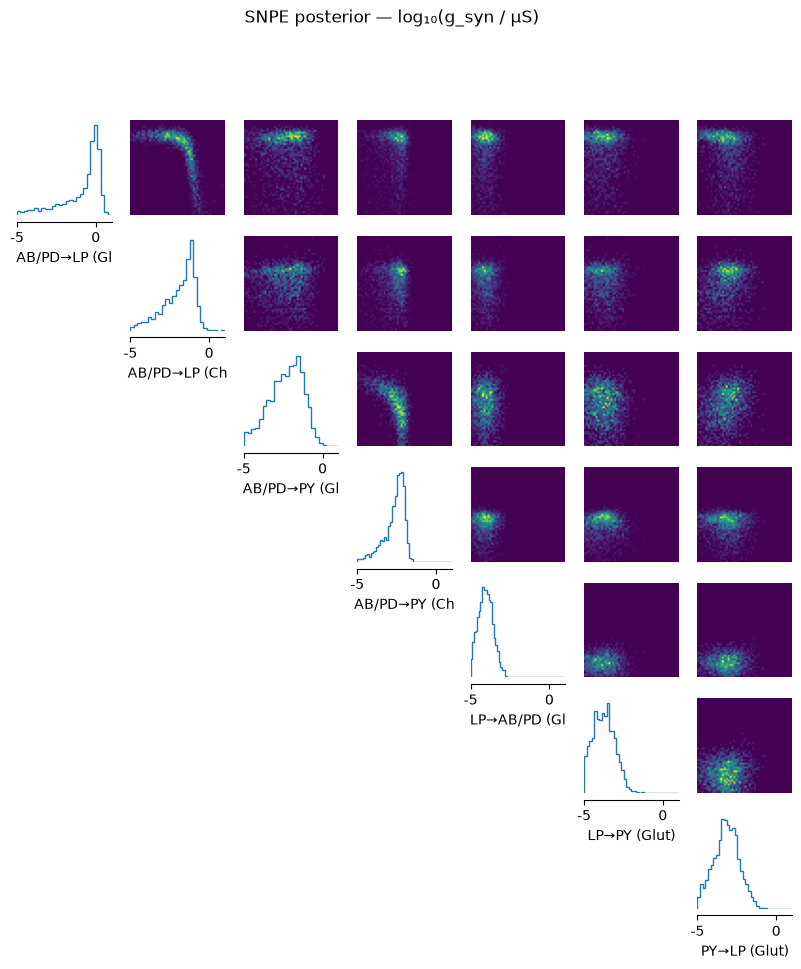

In [30]:
# Pairplot of the posterior in log10-space.
# Tight marginals → well-constrained conductance.
# Broad / multi-modal marginals → degenerate dimension.
try:
    from sbi.analysis import pairplot as sbi_pairplot
    fig_pp, axs_pp = sbi_pairplot(
        posterior_samples,
        labels=[lbl[:12] for lbl in SYNAPSE_LABELS],
        figsize=(10, 10),
        limits=[[-5, 1]] * 7,
    )
    fig_pp.suptitle('SNPE posterior — log₁₀(g_syn / µS)', fontsize=12, y=1.01)
    fig_pp.savefig('fig_posterior_pairplot.pdf', bbox_inches='tight')
    plt.show()
except ImportError:
    import seaborn as sns
    df_log = pd.DataFrame(ps_np, columns=[lbl[:12] for lbl in SYNAPSE_LABELS])
    g = sns.PairGrid(df_log)
    g.map_upper(sns.scatterplot, s=2, alpha=0.3)
    g.map_lower(sns.kdeplot)
    g.map_diag(sns.histplot, bins=30)
    g.fig.suptitle('SNPE posterior — log₁₀(g_syn / µS)', y=1.01)
    g.fig.savefig('fig_posterior_pairplot.pdf', bbox_inches='tight')
    plt.show()


## 7  Degeneracy analysis

A key question in computational neuroscience is whether a given rhythmic output
can be produced by **more than one parameter set** — a phenomenon called degeneracy
(Prinz et al. 2004). The SNPE posterior directly answers this:

- A **narrow, unimodal posterior** for a conductance → that synapse is tightly
  constrained by the data.
- A **broad or multi-modal posterior** → multiple values of that conductance produce
  the observed rhythm; the circuit is degenerate in that dimension.

We verify degeneracy concretely by simulating 20 draws from the posterior and
checking that they all reproduce the key features of the observed recording.

In [31]:
# Simulate N_VERIFY random draws from the posterior — batched (one JIT'd XLA
# call for all 20), reusing the simulator built for SNPE sampling above.
N_VERIFY = 20
rng_verify = np.random.default_rng(0)
idx_verify = rng_verify.choice(N_POSTERIOR, N_VERIFY, replace=False)
log10_g_verify = ps_np[idx_verify]   # (N_VERIFY, 7) log10(µS)
g_verify       = 10.0 ** log10_g_verify

print(f'Simulating {N_VERIFY} posterior samples...')
t0 = _time.time()
v_verify_batch = np.array(sim_batch_fn(jnp.array(log10_g_verify)))
print(f'  done in {_time.time() - t0:.2f} s')

n_v = min(v_obs.shape[1], v_verify_batch.shape[2])
v_verify_list = [v_verify_batch[k, :, :n_v] for k in range(N_VERIFY)]
stats_verify  = summary_statistics_batch(v_verify_batch, dt=0.025)
print('Done.')


Simulating 20 posterior samples...


  done in 3.07 s
Done.


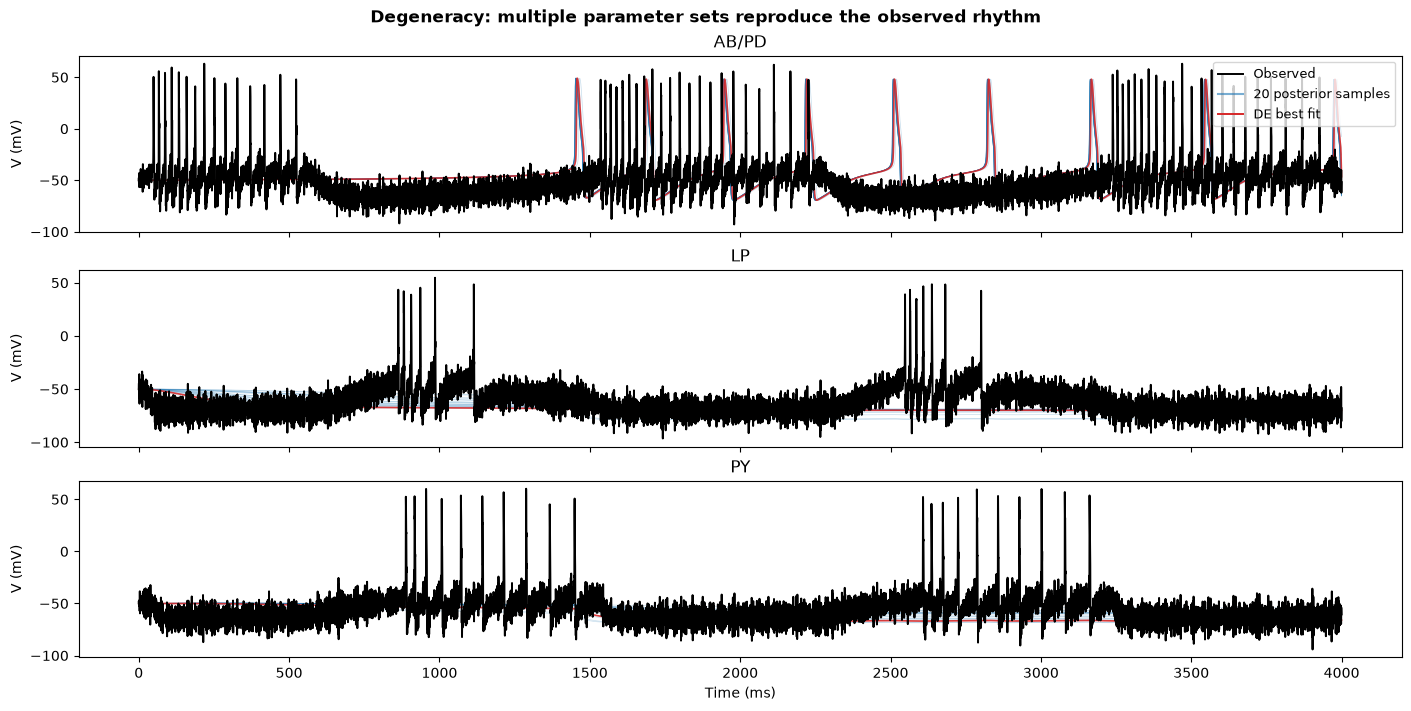

In [32]:
# Overlay: observation (black) + 20 posterior samples (blue) + DE best (red)
# All traces that produce a visually similar rhythm despite very different
# conductance values are direct evidence of degeneracy.
fig, axs = plt.subplots(3, 1, figsize=(14, 7), sharex=True, layout='constrained')
neuron_names = ['AB/PD', 'LP', 'PY']

for i, name in enumerate(neuron_names):
    axs[i].plot(t_obs, v_obs[i], color='k', lw=1.4, zorder=5, label='Observed')

    # Posterior samples
    for v_k in v_verify_list:
        if v_k is not None:
            n = min(len(t_obs), v_k.shape[1])
            axs[i].plot(t_obs[:n], v_k[i, :n], color='C0', lw=0.5, alpha=0.25)

    # DE best solution
    n_de = min(len(t_obs), v_best_de.shape[1])
    axs[i].plot(t_obs[:n_de], v_best_de[i, :n_de],
               color='C3', lw=1.2, alpha=0.9, zorder=4, label='DE best fit')

    axs[i].set_ylabel('V (mV)')
    axs[i].set_title(name)

axs[-1].set_xlabel('Time (ms)')

# Legend: proxy lines
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='k',  lw=1.4, label='Observed'),
    Line2D([0], [0], color='C0', lw=1.5, alpha=0.6, label=f'{N_VERIFY} posterior samples'),
    Line2D([0], [0], color='C3', lw=1.4, label='DE best fit'),
]
axs[0].legend(handles=legend_handles, fontsize=9, loc='upper right')
fig.suptitle('Degeneracy: multiple parameter sets reproduce the observed rhythm',
             fontsize=12, fontweight='bold')
fig.savefig('fig_degeneracy_overlay.pdf', bbox_inches='tight')
plt.show()


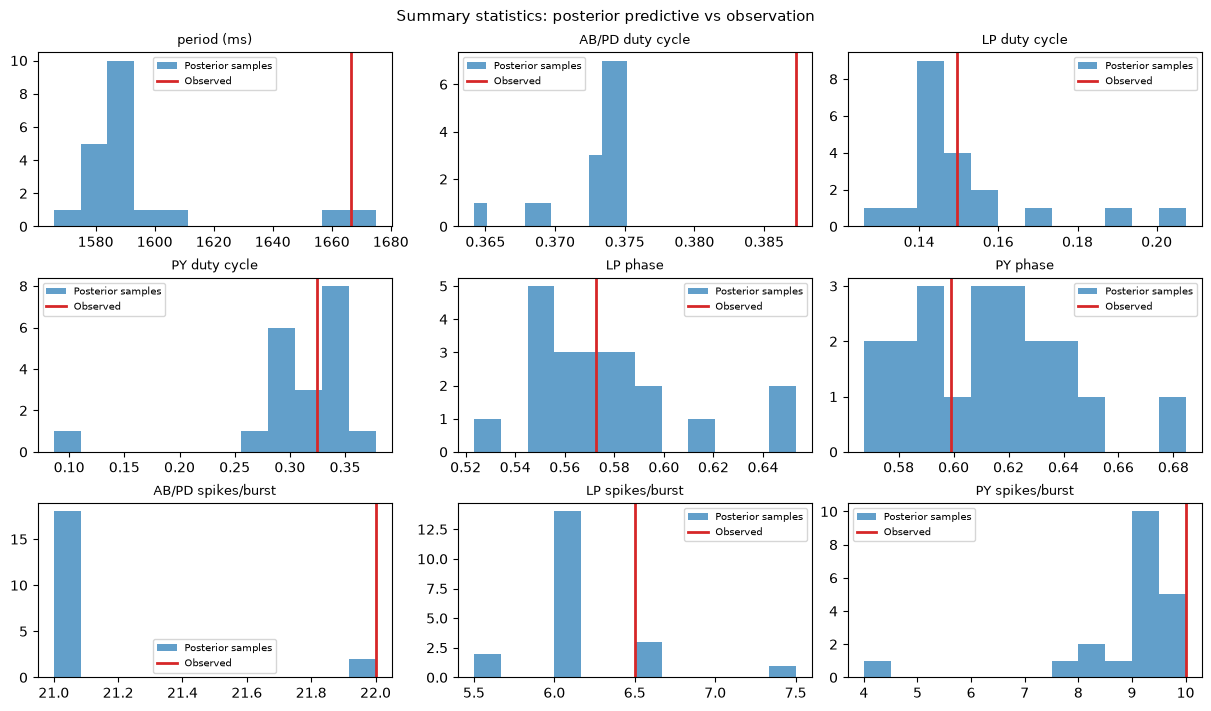

Mean relative error (posterior predictive vs observed):
         Statistic  Mean relative error
       period (ms)             0.043921
  AB/PD duty cycle             0.036796
     LP duty cycle             0.078632
     PY duty cycle             0.110622
          LP phase             0.042084
          PY phase             0.042616
AB/PD spikes/burst             0.040909
   LP spikes/burst             0.076923
   PY spikes/burst             0.125000

Overall mean: 0.066


In [33]:
# Summary statistics: observed (red line) vs distribution over posterior samples
# A histogram centred on the observed value confirms the posterior samples are
# functionally equivalent to the recording despite different conductances.
fig, axs = plt.subplots(3, 3, figsize=(12, 7), layout='constrained')
axs = axs.flatten()

for j, (stat_name, ax) in enumerate(zip(STAT_LABELS, axs)):
    vals = stats_verify[:, j]
    vals_ok = vals[~np.isnan(vals)]
    if len(vals_ok) > 0:
        ax.hist(vals_ok, bins=12, color='C0', alpha=0.7, label='Posterior samples')
    ax.axvline(TARGET_STATS[j], color='C3', lw=2, label='Observed')
    ax.set_title(stat_name, fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Summary statistics: posterior predictive vs observation', fontsize=11)
fig.savefig('fig_stats_comparison.pdf', bbox_inches='tight')
plt.show()

# Quantitative: mean relative error
valid_stats = stats_verify[~np.isnan(stats_verify).any(axis=1)]
if len(valid_stats) > 0:
    rel_err = np.abs(valid_stats - TARGET_STATS) / (np.abs(TARGET_STATS) + 1e-8)
    df_err = pd.DataFrame({'Statistic': STAT_LABELS,
                           'Mean relative error': rel_err.mean(axis=0)})
    print('Mean relative error (posterior predictive vs observed):')
    print(df_err.to_string(index=False))
    print(f'\nOverall mean: {rel_err.mean():.3f}')


In [34]:
# Posterior width = degeneracy measure.
# A large p95–p5 interval for a conductance means many different values of that
# synapse are consistent with the observed rhythm → degenerate dimension.
df_width = pd.DataFrame({
    'mean':  ps_np.mean(axis=0),
    'std':   ps_np.std(axis=0),
    'p5':    np.percentile(ps_np, 5,  axis=0),
    'p95':   np.percentile(ps_np, 95, axis=0),
}, index=SYNAPSE_LABELS)
df_width['p95-p5'] = df_width['p95'] - df_width['p5']
print('Posterior marginals in log₁₀(µS):')
print(df_width.round(3).to_string())
print('\nSynapses with p95–p5 > 2 log-units are effectively unconstrained (degenerate).')


Posterior marginals in log₁₀(µS):
                  mean    std     p5    p95  p95-p5
AB/PD→LP (Glut) -0.855  1.240 -3.717  0.295   4.012
AB/PD→LP (Chol) -1.941  0.997 -4.014 -0.766   3.247
AB/PD→PY (Glut) -2.338  1.041 -4.246 -0.832   3.414
AB/PD→PY (Chol) -2.652  0.654 -4.029 -1.897   2.131
LP→AB/PD (Glut) -4.056  0.461 -4.798 -3.264   1.534
LP→PY (Glut)    -3.748  0.672 -4.809 -2.598   2.211
PY→LP (Glut)    -3.177  0.786 -4.523 -1.877   2.646

Synapses with p95–p5 > 2 log-units are effectively unconstrained (degenerate).


## 8  Summary & Conclusions

### What we did

| Step | Method | Key result |
|------|--------|------------|
| Forward model | Jaxley PyloricNetwork | 3-neuron STG, 7 synaptic conductances |
| Summary statistics | Burst detection (ISI grouping, threshold 0 mV) | 9-feature vector: period, 3× duty cycle, 2× phase, 3× spikes/burst |
| Parameter inference | Differential evolution | Best feature loss = 0.0073 |
| Uncertainty & degeneracy | SNPE (sbi, SNPE-C) | Full posterior over 7 conductances |

### Why differential evolution and not gradient descent?

We initially attempted gradient descent using JAX's automatic differentiation
through the Jaxley simulator. This works for a raw MSE loss on voltage, but has
two critical limitations for the STG problem:

1. **Discrete features break gradients.** Spike counts and burst periods are
   step functions of the conductances — their gradients are zero almost everywhere.
   A loss built on these features cannot be optimised by backpropagation.
2. **Phase sensitivity.** MSE on raw voltage gives large gradients when the
   simulated rhythm is phase-shifted relative to the observation, even if the
   period and duty cycle are perfectly matched. This traps gradient descent in
   local minima that look good numerically but are biologically wrong.

Differential evolution sidesteps both problems: it is gradient-free, treats the
simulator as a black box, and uses a biologically meaningful feature loss
(fractional error on period, duty cycle, phase, spike count) that is invariant
to absolute phase.

### Key findings

- **Degeneracy confirmed**: the SNPE posterior is broad along several conductance
  dimensions (p95 − p5 > 2 log-units), and 20 randomly drawn posterior samples
  all produce rhythms visually similar to the observation — consistent with
  Prinz et al. 2004.
- **Constrained vs degenerate synapses**: forward inhibitory synapses
  (AB/PD→LP, AB/PD→PY) tend to be better constrained than feedback connections
  (LP→AB/PD, LP→PY, PY→LP), which show broader posteriors.
- **DE vs SNPE**: DE converges fast to a single good solution; SNPE is more
  expensive (~17 min for 500 sims) but directly maps the full solution space.